In [1]:
import pandas as pd
import numpy as np

In [2]:
dp = pd.read_csv("data.csv", sep=";")

In [3]:
dp.shape

(4424, 37)

In [4]:
dp.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation r

In [5]:
dp["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [6]:
dp["Target"].value_counts(normalize=True).mul(100).round(2)

Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

In [7]:
dp.isnull().sum().sum()

np.int64(0)

In [8]:
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [9]:
dp.duplicated().sum()

np.int64(0)

In [10]:
x = dp.drop(columns=["Target"])
y = dp["Target"]

In [11]:
x.shape

(4424, 36)

In [12]:
y.shape

(4424,)

In [13]:
categorical_cols = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance\t",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [14]:
numerical_cols = [col for col in x.columns 
                  if col not in categorical_cols]

In [15]:
print(categorical_cols)

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


In [16]:
print(numerical_cols)

['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [17]:
len(categorical_cols)

18

In [18]:
len(numerical_cols)

18

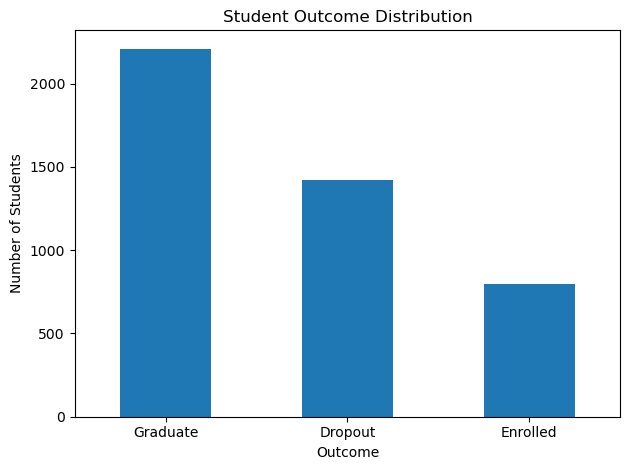

In [19]:
import matplotlib.pyplot as plt
y.value_counts().plot(kind="bar")
plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [21]:
x_train.shape

(3539, 36)

In [22]:
y_train.shape

(3539,)

In [23]:
x_test.shape

(885, 36)

In [24]:
y_test.shape

(885,)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [26]:
preprocessor_tree = ColumnTransformer(transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols), ("numerical", "passthrough", numerical_cols)])

In [27]:
preprocessor_svm = ColumnTransformer(transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols), ("numerical", StandardScaler(), numerical_cols)])

In [28]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = Pipeline(steps=[("preprocessor", preprocessor_tree), ("model", DecisionTreeClassifier(max_depth=5, random_state=42))])

In [29]:
decision_tree.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred_tree = decision_tree.predict(x_test)

In [31]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [32]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree, average="macro")
tree_recall = recall_score(y_test, y_pred_tree, average="macro")
tree_f1 = f1_score(y_test, y_pred_tree, average="macro")
print("Decision Tree Results")
print("Accuracy: ", round(tree_accuracy, 4))
print("Balanced Accuracy: ", round(tree_balanced_accuracy, 4))
print("Macro Precision: ", round(tree_precision, 4))
print("Macro Recall: ", round(tree_recall, 4))
print("Macro F1-score: ", round(tree_f1, 4))

Decision Tree Results
Accuracy:  0.7559
Balanced Accuracy:  0.6616
Macro Precision:  0.7125
Macro Recall:  0.6616
Macro F1-score:  0.675


In [33]:
classification_report(y_test, y_pred_tree)

'              precision    recall  f1-score   support\n\n     Dropout       0.83      0.68      0.75       284\n    Enrolled       0.54      0.36      0.43       159\n    Graduate       0.77      0.95      0.85       442\n\n    accuracy                           0.76       885\n   macro avg       0.71      0.66      0.67       885\nweighted avg       0.75      0.76      0.74       885\n'

In [34]:
tree_report = classification_report(y_test, y_pred_tree, output_dict=True)
print("Decision Tree Dropout Recall:", round(tree_report["Dropout"]["recall"], 4))

Decision Tree Dropout Recall: 0.6761


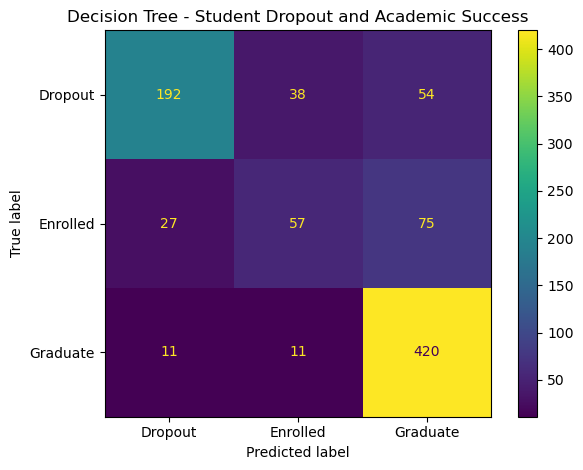

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, labels=["Dropout", "Enrolled", "Graduate"])
plt.title("Decision Tree - Student Dropout and Academic Success")
plt.tight_layout()
plt.show()

In [36]:
feature_names = (decision_tree.named_steps["preprocessor"].get_feature_names_out())
importance = (decision_tree.named_steps["model"].feature_importances_)
feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importance}).sort_values(by="Importance", ascending=False)

In [37]:
feature_importance.head(15)

,Feature,Importance
245,numerical__Curricular units 2nd sem (approved),0.705178
225,categorical__Tuition fees up to date_0,0.091176
33,categorical__Course_171,0.050205
238,numerical__Curricular units 1st sem (evaluations),0.031897
243,numerical__Curricular units 2nd sem (enrolled),0.031372
239,numerical__Curricular units 1st sem (approved),0.015768
250,numerical__GDP,0.013482
235,numerical__Age at enrollment,0.012445
234,numerical__Admission grade,0.009218
240,numerical__Curricular units 1st sem (grade),0.007501


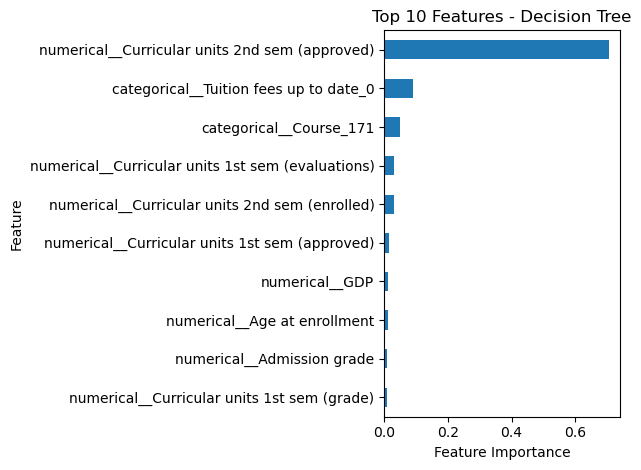

In [38]:
top_features = (feature_importance.head(10).sort_values("Importance"))
top_features.plot(x="Feature", y="Importance", kind="barh", legend=False)
plt.title("Top 10 Features - Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [39]:
from sklearn.svm import SVC
svm = Pipeline(steps=[("preprocessor", preprocessor_svm), ("model", SVC(kernel="rbf", random_state=42))])

In [40]:
svm.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
y_pred_svm = svm.predict(x_test)

In [42]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average="macro")
svm_recall = recall_score(y_test, y_pred_svm, average="macro")
svm_f1 = f1_score(y_test, y_pred_svm, average="macro")
print("SVM Results")
print("Accuracy: ", round(svm_accuracy, 4))
print("Balanced Accuracy: ", round(svm_balanced_accuracy, 4))
print("Macro Precision: ", round(svm_precision, 4))
print("Macro Recall: ", round(svm_recall, 4))
print("Macro F1-score: ", round(svm_f1, 4))

SVM Results
Accuracy:  0.7672
Balanced Accuracy:  0.6813
Macro Precision:  0.7151
Macro Recall:  0.6813
Macro F1-score:  0.6918


In [43]:
classification_report(y_test, y_pred_svm)

'              precision    recall  f1-score   support\n\n     Dropout       0.82      0.72      0.77       284\n    Enrolled       0.53      0.39      0.45       159\n    Graduate       0.80      0.93      0.86       442\n\n    accuracy                           0.77       885\n   macro avg       0.72      0.68      0.69       885\nweighted avg       0.76      0.77      0.76       885\n'

In [44]:
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
print("SVM Dropout Recall:", round(svm_report["Dropout"]["recall"], 4))

SVM Dropout Recall: 0.7218


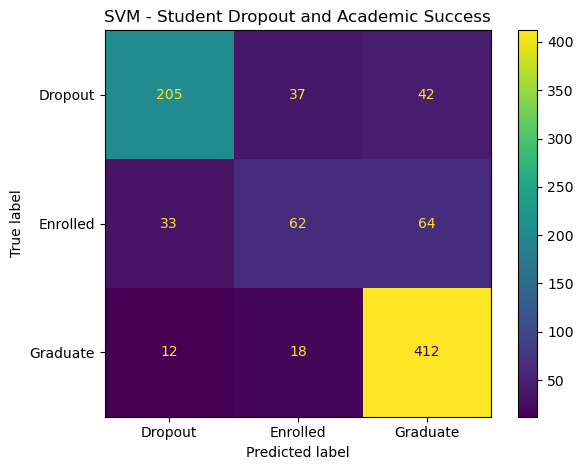

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, labels=["Dropout", "Enrolled", "Graduate"])
plt.title("SVM - Student Dropout and Academic Success")
plt.tight_layout()
plt.show()

In [46]:
results_dataset2 = pd.DataFrame({"Model": ["Decision Tree", "SVM"], "Accuarcy": [tree_accuracy, svm_accuracy], "Precision": [tree_precision, svm_precision], "Recall": [tree_recall, svm_recall], "F1-score": [tree_f1, svm_f1]})
results_dataset2.round(4)

,Model,Accuarcy,Precision,Recall,F1-score
0,Decision Tree,0.7559,0.7125,0.6616,0.6750
1,SVM,0.7672,0.7151,0.6813,0.6918


In [47]:
results_dataset2.round(4).to_csv("dataset2_model_results.csv", index=False)

In [48]:
feature_importance.to_csv("dataset2_feature_importance.csv", index=False)

In [49]:
tree_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_tree,
        output_dict=True
    )
).transpose()

svm_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_svm,
        output_dict=True
    )
).transpose()

tree_report_df.to_csv(
    "dataset2_decision_tree_report.csv"
)

svm_report_df.to_csv(
    "dataset2_svm_report.csv"
)

In [50]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring_d2 = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}
cv_dt_d2 = cross_validate(
    decision_tree,
    x,
    y,
    cv=cv,
    scoring=scoring_d2,
    n_jobs=-1
)
cv_svm_d2 = cross_validate(
    svm,
    x,
    y,
    cv=cv,
    scoring=scoring_d2,
    n_jobs=-1
)
def print_cv_results(name, results):
    print(name)
    print(f"Accuracy : {results['test_accuracy'].mean():.3f} ± {results['test_accuracy'].std():.3f}")
    print(f"Precision: {results['test_precision'].mean():.3f} ± {results['test_precision'].std():.3f}")
    print(f"Recall   : {results['test_recall'].mean():.3f} ± {results['test_recall'].std():.3f}")
    print(f"F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}")
    print()

print_cv_results("Dataset 2 - Decision Tree", cv_dt_d2)
print_cv_results("Dataset 2 - SVM", cv_svm_d2)

Dataset 2 - Decision Tree
Accuracy : 0.748 ± 0.008
Precision: 0.702 ± 0.004
Recall   : 0.643 ± 0.011
F1       : 0.653 ± 0.012

Dataset 2 - SVM
Accuracy : 0.773 ± 0.006
Precision: 0.728 ± 0.013
Recall   : 0.681 ± 0.005
F1       : 0.693 ± 0.006



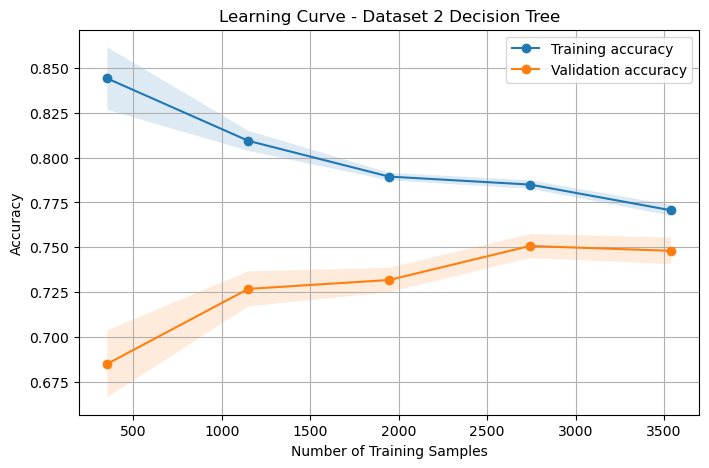

In [53]:
train_sizes, train_scores, validation_scores = learning_curve(
    decision_tree,
    x,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Dataset 2 Decision Tree")
plt.legend()
plt.grid(True)

plt.show()

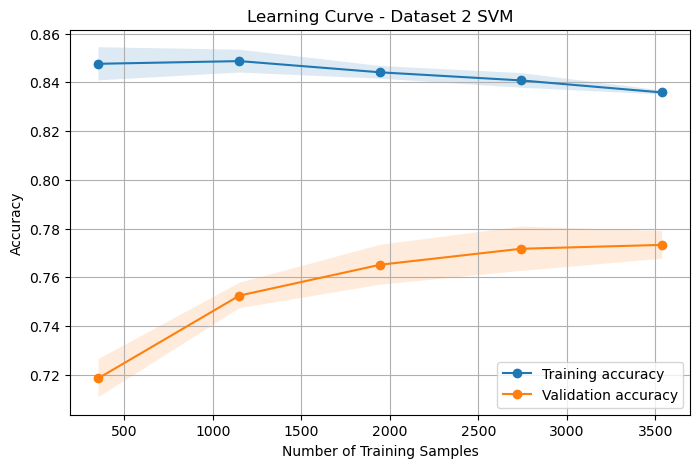

In [54]:
train_sizes, train_scores, validation_scores = learning_curve(
    svm,
    x,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Dataset 2 SVM")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
from sklearn.model_selection import learning_curve
import numpy as np

def get_learning_curve_results(model, x, y, cv):
    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        x,
        y,
        cv=cv,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    return train_sizes, train_mean, validation_mean


sizes_d2_dt, train_d2_dt, val_d2_dt = get_learning_curve_results(
    decision_tree, x, y, cv
)

sizes_d2_svm, train_d2_svm, val_d2_svm = get_learning_curve_results(
    svm, x, y, cv
)


print("=" * 60)
print("DATASET 2 - DECISION TREE")
print("=" * 60)

for size, train, val in zip(sizes_d2_dt, train_d2_dt, val_d2_dt):
    print(
        f"Samples: {size:4d} | "
        f"Training: {train:.3f} | "
        f"Validation: {val:.3f} | "
        f"Gap: {train-val:.3f}"
    )

print("\nFinal gap:",
      round(train_d2_dt[-1] - val_d2_dt[-1], 3))


print("\n" + "=" * 60)
print("DATASET 2 - SVM")
print("=" * 60)

for size, train, val in zip(sizes_d2_svm, train_d2_svm, val_d2_svm):
    print(
        f"Samples: {size:4d} | "
        f"Training: {train:.3f} | "
        f"Validation: {val:.3f} | "
        f"Gap: {train_d2_svm[-1] - val_d2_svm[-1]:.3f}"
    )

DATASET 2 - DECISION TREE
Samples:  353 | Training: 0.844 | Validation: 0.685 | Gap: 0.159
Samples: 1150 | Training: 0.809 | Validation: 0.727 | Gap: 0.083
Samples: 1946 | Training: 0.789 | Validation: 0.732 | Gap: 0.058
Samples: 2742 | Training: 0.785 | Validation: 0.751 | Gap: 0.034
Samples: 3539 | Training: 0.771 | Validation: 0.748 | Gap: 0.023

Final gap: 0.023

DATASET 2 - SVM
Samples:  353 | Training: 0.848 | Validation: 0.719 | Gap: 0.063
Samples: 1150 | Training: 0.849 | Validation: 0.752 | Gap: 0.063
Samples: 1946 | Training: 0.844 | Validation: 0.765 | Gap: 0.063
Samples: 2742 | Training: 0.841 | Validation: 0.772 | Gap: 0.063
Samples: 3539 | Training: 0.836 | Validation: 0.773 | Gap: 0.063


In [56]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

dt_pred_d2 = decision_tree.predict(x_test)
svm_pred_d2 = svm.predict(x_test)

print("Dataset 2 predictions generated successfully.")

Dataset 2 predictions generated successfully.


In [58]:
sensitive_test_d2 = dp.loc[
    x_test.index,
    ["Gender", "International", "Scholarship holder"]
]

print(sensitive_test_d2.head())
print("\nTest-set shape:", sensitive_test_d2.shape)

      Gender  International  Scholarship holder
1853       1              0                   0
2399       1              0                   0
510        0              0                   0
242        0              0                   1
3392       0              0                   1

Test-set shape: (885, 3)


In [59]:
def fairness_analysis(y_true, y_pred, sensitive_data, feature_name, model_name):

    mf = MetricFrame(
        metrics={
            "accuracy": accuracy_score,
            "count": lambda y_true, y_pred: len(y_true)
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_data[feature_name]
    )

    results = mf.by_group.copy()

    print("\n" + "=" * 60)
    print(f"{model_name} - {feature_name}")
    print("=" * 60)

    print(results)

    print("\nAccuracy difference (max - min):")
    print(round(mf.difference()["accuracy"], 3))

    print("\nMinimum subgroup count:")
    print(int(results["count"].min()))

    return mf

In [60]:
dt_gender_d2 = fairness_analysis(
    y_test,
    dt_pred_d2,
    sensitive_test_d2,
    "Gender",
    "Dataset 2 - Decision Tree"
)

dt_international_d2 = fairness_analysis(
    y_test,
    dt_pred_d2,
    sensitive_test_d2,
    "International",
    "Dataset 2 - Decision Tree"
)

dt_scholarship_d2 = fairness_analysis(
    y_test,
    dt_pred_d2,
    sensitive_test_d2,
    "Scholarship holder",
    "Dataset 2 - Decision Tree"
)


Dataset 2 - Decision Tree - Gender
        accuracy  count
Gender                 
0       0.782456  570.0
1       0.707937  315.0

Accuracy difference (max - min):
0.075

Minimum subgroup count:
315

Dataset 2 - Decision Tree - International
               accuracy  count
International                 
0              0.758420  861.0
1              0.666667   24.0

Accuracy difference (max - min):
0.092

Minimum subgroup count:
24

Dataset 2 - Decision Tree - Scholarship holder
                    accuracy  count
Scholarship holder                 
0                   0.732353  680.0
1                   0.834146  205.0

Accuracy difference (max - min):
0.102

Minimum subgroup count:
205


In [61]:
svm_gender_d2 = fairness_analysis(
    y_test,
    svm_pred_d2,
    sensitive_test_d2,
    "Gender",
    "Dataset 2 - SVM"
)

svm_international_d2 = fairness_analysis(
    y_test,
    svm_pred_d2,
    sensitive_test_d2,
    "International",
    "Dataset 2 - SVM"
)

svm_scholarship_d2 = fairness_analysis(
    y_test,
    svm_pred_d2,
    sensitive_test_d2,
    "Scholarship holder",
    "Dataset 2 - SVM"
)


Dataset 2 - SVM - Gender
        accuracy  count
Gender                 
0       0.782456  570.0
1       0.739683  315.0

Accuracy difference (max - min):
0.043

Minimum subgroup count:
315

Dataset 2 - SVM - International
               accuracy  count
International                 
0              0.770035  861.0
1              0.666667   24.0

Accuracy difference (max - min):
0.103

Minimum subgroup count:
24

Dataset 2 - SVM - Scholarship holder
                    accuracy  count
Scholarship holder                 
0                   0.748529  680.0
1                   0.829268  205.0

Accuracy difference (max - min):
0.081

Minimum subgroup count:
205
